# 05 — Climate Features (ERA5-Land via GEE)

Extract per-cell temperature and wind statistics from ERA5-Land.
PRISM does not cover Hawaii — ERA5-Land (`ECMWF/ERA5_LAND/DAILY_AGGR`) is used instead:
- **~9 km resolution**, daily, global, back to 1950
- Covers temperature, wind, precipitation, humidity in one dataset

## Workflow
1. **Export**: Aggregate ERA5-Land to monthly composites per cell → Drive CSV (one per year)
2. **Download**: Download CSVs from Drive → `../data/climate/`
3. **Process**: Derive annual + seasonal summary features per cell
4. **Save**: `../data/plot_climate_features.pkl`

## Features derived

| Feature | Description |
|---|---|
| `temp_mean` | Annual mean 2m temperature (°C) |
| `temp_min` | Mean of daily minimums — frost/cold-stress proxy |
| `temp_max` | Mean of daily maximums — heat-stress proxy |
| `temp_range` | Mean diurnal range (max − min) |
| `gdd` | Growing degree days (base 10 °C) |
| `cold_days` | Days where daily min < 10 °C (coffee cold-stress threshold) |
| `precip_annual` | Total annual precipitation (mm) |
| `precip_dry` | Precip during dry season (Jun–Sep, Kona leeward) |
| `wind_speed_mean` | Annual mean 10m wind speed (m/s) |
| `wind_u_mean` | Mean eastward wind component |
| `wind_v_mean` | Mean northward wind component |
| `wind_speed_max` | Peak monthly mean wind speed |

**Prerequisites:** run `06` auth cell, CSVs in `../data/climate/`.

In [1]:
import ee
import pandas as pd
import numpy as np
import geopandas as gpd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

CLIMATE_DIR = '../data/climate'
os.makedirs(CLIMATE_DIR, exist_ok=True)

# Match the NDVI year range
YEARS = list(range(2017, 2026))

# ERA5-Land bands to export
MEAN_BANDS = [
    'temperature_2m',
    'temperature_2m_min',
    'temperature_2m_max',
    'u_component_of_wind_10m',
    'v_component_of_wind_10m',
    'dewpoint_temperature_2m',
]
SUM_BANDS = ['total_precipitation_sum']

# ── Downloaded flag ───────────────────────────────────────────────────────────
downloaded = False

climate_files      = [f'climate_{year}.csv' for year in YEARS]
climate_file_paths = [os.path.join(CLIMATE_DIR, f) for f in climate_files]

if all(os.path.isfile(p) for p in climate_file_paths):
    downloaded = True
    print('All climate CSVs found — skipping GEE export.')
else:
    missing = [f for f, p in zip(climate_files, climate_file_paths) if not os.path.isfile(p)]
    print(f'Missing {len(missing)} file(s): {missing[:3]}{"..." if len(missing) > 3 else ""}')

/home/simonhans/anaconda3/lib/python3.7/site-packages/google/auth/crypt/_cryptography_rsa.py:22: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.7.
  import cryptography.exceptions
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


All climate CSVs found — skipping GEE export.


In [2]:
# ── Google Earth Engine authentication ───────────────────────────────────────
# Run this cell once whenever your credentials expire.
import ee
ee.Authenticate()
ee.Initialize(project='ee-simonhansedasi')
print('GEE authenticated and initialized.')

GEE authenticated and initialized.


In [3]:
if not downloaded:
    # Load coffee cells only (same subset as 04_ndvi)
    grid = pd.read_pickle('../data/polygons/kona_grid.pkl')   # EPSG:4326
    grid_export = grid[grid['label'] == 1].copy()
    print(f'Total grid: {len(grid):,}  →  exporting {len(grid_export):,} coffee cells')

    from shapely.geometry import Polygon, MultiPolygon

    def shapely_to_ee_feature(poly, plot_id):
        if poly.geom_type == 'Polygon':
            return ee.Feature(
                ee.Geometry.Polygon(list(poly.exterior.coords)),
                {'plot_id': plot_id}
            )
        elif poly.geom_type == 'MultiPolygon':
            p = list(poly.geoms)[0]
            return ee.Feature(
                ee.Geometry.Polygon(list(p.exterior.coords)),
                {'plot_id': plot_id}
            )

    ee_features = []
    for _, row in tqdm(grid_export.iterrows(), total=len(grid_export), desc='Building EE features'):
        ee_features.append(shapely_to_ee_feature(row.geometry, int(row['plot_id'])))

    hex_fc = ee.FeatureCollection(ee_features)
    print(f'EE FeatureCollection: {len(ee_features)} features')
else:
    print('Skipping GEE setup — CSVs already downloaded.')

Skipping GEE setup — CSVs already downloaded.


In [4]:
if not downloaded:
    # ── Reduction helper ────────────────────────────────────────────────────
    def reduce_climate(img, geom, plot_id, year, month):
        """Sample ERA5-Land at the cell centroid.

        Using centroid instead of the full polygon avoids the empty-pixel
        problem: small hex cells (~1 km) can fall between 9 km ERA5 grid
        points, causing reduceRegion to return null for every band.
        A point geometry always hits exactly one pixel.

        Properties are set directly from the stats dict so the raw ERA5
        band names appear as CSV columns — no stats.get() needed.
        """
        centroid = geom.centroid(maxError=100)
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=centroid,
            scale=9000,
            bestEffort=True,
            maxPixels=1e9,
        )
        return (ee.Feature(None, stats)
                .set('plot_id', plot_id)
                .set('year',    year)
                .set('month',   month))
else:
    print('Skipping function definitions.')

Skipping function definitions.


In [5]:
if not downloaded:
    # ── Submit one export task per year ──────────────────────────────────────
    # Strategy: aggregate ERA5-Land to monthly composites server-side, then
    # reduceRegion per cell per month. One CSV per year with
    # columns: plot_id, year, month, temp_mean, temp_min, temp_max,
    #          dewpoint, wind_u, wind_v, precip

    era5 = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
    months = list(range(1, 13))

    for year in YEARS:
        out_path = os.path.join(CLIMATE_DIR, f'climate_{year}.csv')
        if os.path.isfile(out_path):
            print(f'  {year}: CSV already exists, skipping.')
            continue

        def make_monthly_features(m):
            m = ee.Number(m)
            monthly = (era5
                .filterBounds(hex_fc)
                .filter(ee.Filter.calendarRange(year, year, 'year'))
                .filter(ee.Filter.calendarRange(m, m, 'month'))
                .select(MEAN_BANDS + SUM_BANDS)
            )
            # Mean for temp/wind/dewpoint, sum for precip
            mean_img = monthly.select(MEAN_BANDS).mean()
            sum_img  = monthly.select(SUM_BANDS).sum()
            composite = mean_img.addBands(sum_img)

            cell_features = hex_fc.map(
                lambda f: reduce_climate(
                    composite,
                    f.geometry(),
                    f.get('plot_id'),
                    year,
                    m
                )
            )
            return cell_features

        # Map over months and flatten to one FeatureCollection
        all_months_fc = ee.FeatureCollection(
            ee.List(months).map(make_monthly_features)
        ).flatten()

        description = f'climate_{year}'
        task = ee.batch.Export.table.toDrive(
            collection=all_months_fc,
            description=description,
            folder=f'ee_climate_exports_{year}',
            fileFormat='CSV',
        )
        task.start()
        print(f'  {year}: export task submitted → ee_climate_exports_{year}')

    print('All tasks submitted.')
else:
    print('Already exported.')

Already exported.


In [6]:
# #### ── Live task monitor ─────────────────────────────────────────────────────────
# import time
# from IPython.display import clear_output

# POLL_INTERVAL = 30

# while True:
#     clear_output(wait=True)
#     now = time.time()
#     tasks = [t for t in ee.batch.Task.list()
#              if t.config.get('description', '').startswith('climate_')]

#     total   = len(tasks)
#     n_done  = sum(1 for t in tasks if t.state == 'COMPLETED')
#     n_fail  = sum(1 for t in tasks if t.state == 'FAILED')
#     n_ready = sum(1 for t in tasks if t.state == 'READY')
#     n_run   = sum(1 for t in tasks if t.state == 'RUNNING')

#     print(f'=== ERA5-Land climate monitor  [{time.strftime("%H:%M:%S")}] ===')
#     print(f'  {n_done}/{total} completed   {n_run} running   {n_ready} queued   {n_fail} failed')
#     print()

#     for t in sorted(tasks, key=lambda x: x.config.get('description', '')):
#         desc   = t.config.get('description', t.id)
#         st     = t.state
#         status = t.status()
#         elapsed_str = ''
#         if st in ('RUNNING', 'COMPLETED', 'FAILED'):
#             start_ms = status.get('start_timestamp_ms')
#             if start_ms:
#                 end_ms = status.get('update_timestamp_ms') or int(now * 1000)
#                 elapsed_str = f'  {(end_ms - start_ms)/60000:.1f} min'
#         err = '  ERROR: ' + status.get('error_message', '') if st == 'FAILED' else ''
#         print(f'  {desc:40s}  {st}{elapsed_str}{err}')

#     if all(t.state in ('COMPLETED', 'FAILED') for t in tasks):
#         print('\nAll tasks finished.')
#         break

#     print(f'\n  (refreshing in {POLL_INTERVAL}s — interrupt to stop)')
#     time.sleep(POLL_INTERVAL)

In [7]:
# ── Load downloaded CSVs ──────────────────────────────────────────────────────
# GEE exports raw ERA5 band names as column headers.
# Rename them here so the rest of the pipeline uses friendlier names.

ERA5_RENAME = {
    'temperature_2m':          'temp_mean',
    'temperature_2m_min':      'temp_min',
    'temperature_2m_max':      'temp_max',
    'dewpoint_temperature_2m': 'dewpoint',
    'u_component_of_wind_10m': 'wind_u',
    'v_component_of_wind_10m': 'wind_v',
    'total_precipitation_sum': 'precip',
}
KELVIN_OFFSET = 273.15

dfs = []
for year, fpath in zip(YEARS, climate_file_paths):
    if not os.path.isfile(fpath):
        print(f'  WARNING: {os.path.basename(fpath)} not found — skipping {year}')
        continue
    tmp = pd.read_csv(fpath)
    tmp = tmp.rename(columns=ERA5_RENAME)

    required = {'plot_id', 'year', 'month', 'temp_mean', 'wind_u', 'wind_v', 'precip'}
    missing_cols = required - set(tmp.columns)
    if missing_cols:
        print(f'  WARNING: {year} missing columns {missing_cols} — skipping')
        continue

    # Unit conversions
    for col in ['temp_mean', 'temp_min', 'temp_max', 'dewpoint']:
        if col in tmp.columns:
            tmp[col] = tmp[col].replace(-9999, float('nan'))
            valid = tmp[col].notna()
            tmp.loc[valid, col] = tmp.loc[valid, col] - KELVIN_OFFSET

    for col in ['wind_u', 'wind_v']:
        tmp[col] = tmp[col].replace(-9999, float('nan'))

    # Precip: metres → mm
    tmp['precip'] = tmp['precip'].replace(-9999, float('nan')) * 1000

    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
df['plot_id'] = df['plot_id'].astype(int)
df['year']    = df['year'].astype(int)
df['month']   = df['month'].astype(int)

# Derived wind fields
df['wind_speed'] = np.sqrt(df['wind_u']**2 + df['wind_v']**2)
wind_dir_rad = np.arctan2(df['wind_u'], df['wind_v'])
df['wind_dir_sin'] = np.sin(wind_dir_rad)
df['wind_dir_cos'] = np.cos(wind_dir_rad)

print(f'Loaded {len(df):,} cell-month observations across {df["plot_id"].nunique():,} cells, {df["year"].nunique()} years')
df.head()

Loaded 50,868 cell-month observations across 471 cells, 9 years


,system:index,dewpoint,month,plot_id,temp_mean,temp_max,temp_min,precip,wind_u,wind_v,year,.geo,wind_speed,wind_dir_sin,wind_dir_cos
0,0_0,17.343205,1,211,22.098528,23.495419,21.210366,25.345972,-6.722548,-0.908385,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",6.783643,-0.990994,-0.133908
1,0_1,17.343205,1,212,22.098528,23.495419,21.210366,25.345972,-6.722548,-0.908385,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",6.783643,-0.990994,-0.133908
2,0_2,17.343205,1,213,22.098528,23.495419,21.210366,25.345972,-6.722548,-0.908385,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",6.783643,-0.990994,-0.133908
3,0_3,17.343205,1,214,22.098528,23.495419,21.210366,25.345972,-6.722548,-0.908385,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",6.783643,-0.990994,-0.133908
4,0_4,12.970344,1,656,18.081509,21.772477,15.564911,44.024741,-2.929868,-1.020422,2017,"{""type"":""MultiPoint"",""coordinates"":[]}",3.102481,-0.944363,-0.328905


In [8]:
# ── Derive per-cell summary features ─────────────────────────────────────────
# Aggregate monthly observations to annual means across all available years,
# then compute seasonal contrasts and derived indices.

DRY_MONTHS  = [6, 7, 8, 9]   # Kona leeward dry season
COLD_THRESH = 10.0             # °C — coffee cold-stress threshold
HEAT_THRESH = 30.0             # °C — coffee heat-stress threshold
GDD_BASE    = 10.0             # °C — growing degree day base for coffee

records = []
for plot_id, grp in tqdm(df.groupby('plot_id'), desc='Cells'):
    grp = grp.dropna(subset=['temp_mean', 'wind_speed'])
    if len(grp) < 6:
        continue

    dry   = grp[grp['month'].isin(DRY_MONTHS)]
    wet   = grp[~grp['month'].isin(DRY_MONTHS)]

    # GDD: clamp daily mean above base, sum across months
    # Using monthly mean temp as proxy for daily mean
    gdd = grp['temp_mean'].apply(lambda t: max(t - GDD_BASE, 0)).sum()

    # Cold / heat stress months
    cold_months = (grp['temp_min'] < COLD_THRESH).sum()
    heat_months = (grp['temp_max'] > HEAT_THRESH).sum()

    records.append({
        'plot_id':          plot_id,

        # Temperature
        'temp_mean':        grp['temp_mean'].mean(),
        'temp_min':         grp['temp_min'].mean(),
        'temp_max':         grp['temp_max'].mean(),
        'temp_range':       (grp['temp_max'] - grp['temp_min']).mean(),
        'gdd':              gdd,
        'cold_months':      cold_months,
        'heat_months':      heat_months,

        # Precipitation
        'precip_annual':    grp['precip'].sum() / grp['year'].nunique(),
        'precip_dry':       dry['precip'].sum()  / grp['year'].nunique(),
        'precip_wet':       wet['precip'].sum()  / grp['year'].nunique(),
        'precip_dry_frac':  (dry['precip'].sum() /
                             (grp['precip'].sum() + 1e-9)),

        # Wind
        'wind_speed_mean':  grp['wind_speed'].mean(),
        'wind_speed_max':   grp['wind_speed'].max(),
        'wind_u_mean':      grp['wind_u'].mean(),
        'wind_v_mean':      grp['wind_v'].mean(),
        'wind_dir_sin':     grp['wind_dir_sin'].mean(),
        'wind_dir_cos':     grp['wind_dir_cos'].mean(),
    })

climate_features = pd.DataFrame(records)
climate_features.to_pickle('../data/plot_climate_features.pkl')
print(f'Saved ../data/plot_climate_features.pkl  ({len(climate_features):,} cells)')
climate_features.describe().round(2)

Cells: 100%|██████████| 471/471 [00:02<00:00, 230.72it/s]


Saved ../data/plot_climate_features.pkl  (385 cells)


,plot_id,temp_mean,temp_min,temp_max,temp_range,gdd,cold_months,heat_months,precip_annual,precip_dry,precip_wet,precip_dry_frac,wind_speed_mean,wind_speed_max,wind_u_mean,wind_v_mean,wind_dir_sin,wind_dir_cos
count,385.00,385.00,385.00,385.00,385.00,385.00,385.0,385.0,385.00,385.00,385.00,385.00,385.00,385.00,385.00,385.00,385.00,385.00
mean,6286.72,18.59,15.89,21.77,5.88,928.12,0.0,0.0,5431.55,2667.23,2764.33,0.45,1.36,2.18,0.19,-0.05,0.58,0.02
std,2371.79,1.18,1.30,1.16,0.71,127.24,0.0,0.0,2257.08,1198.98,1058.46,0.10,0.98,1.15,1.59,0.42,0.73,0.21
min,211.00,15.90,12.75,19.84,2.66,637.55,0.0,0.0,701.72,148.87,552.86,0.21,0.48,0.96,-6.61,-1.62,-0.98,-0.37
25%,4948.00,18.04,15.58,20.80,5.23,868.46,0.0,0.0,5345.12,2643.94,2701.18,0.49,0.97,1.68,0.54,-0.07,0.83,-0.15
50%,6941.00,19.12,16.18,22.07,6.17,984.47,0.0,0.0,6278.09,3129.77,3148.32,0.50,1.07,1.91,0.95,-0.02,0.94,-0.04
75%,8277.00,19.12,16.18,22.35,6.41,984.47,0.0,0.0,7112.81,3553.80,3559.02,0.50,1.09,2.00,1.01,0.23,0.97,0.20
max,10043.00,23.76,22.64,25.36,7.10,1485.95,0.0,0.0,7858.15,3922.00,3936.16,0.50,6.72,8.63,1.01,0.67,0.97,0.60


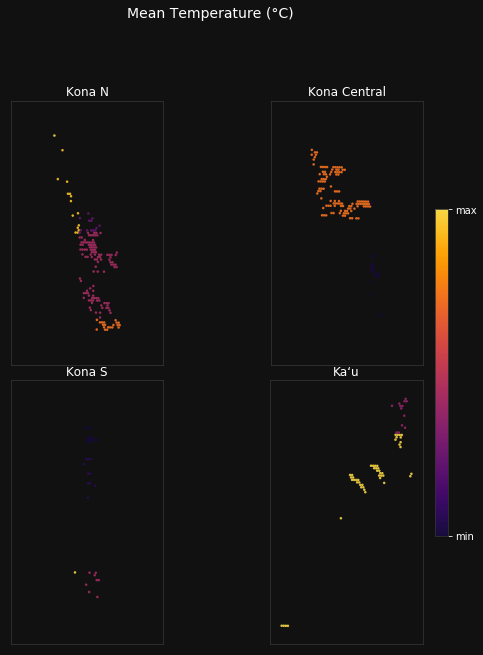

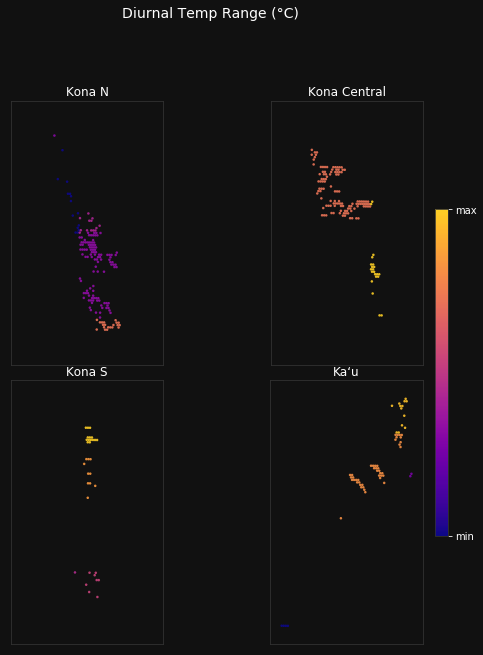

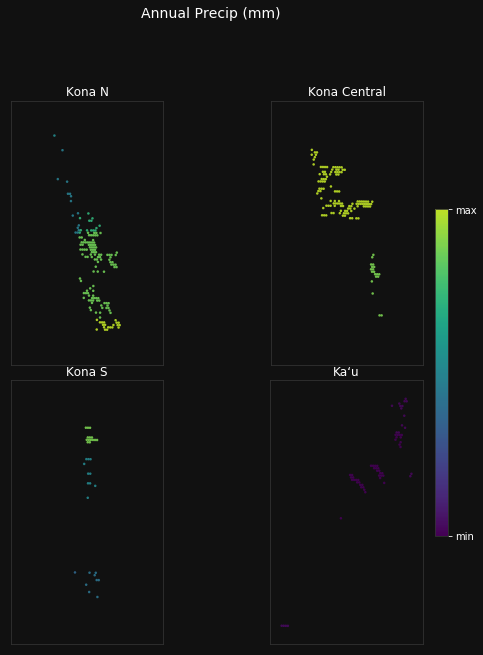

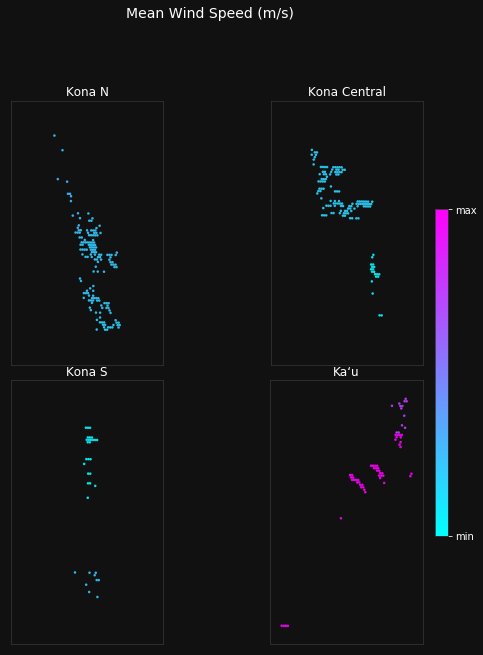

In [9]:
import warnings
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')

SPLIT_LON = -155.7279
BG = '#111111'

def clip_cmap(name, lo=0.0, hi=0.9):
    """Clip colormap to avoid the near-white tip at the bright end."""
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(
        f'{name}_clip', base(np.linspace(lo, hi, 256))
    )

def plot_regions(gdf, col, title, cmap, fname):
    cx = gdf.geometry.centroid.x
    cy = gdf.geometry.centroid.y

    kona = gdf[cx < SPLIT_LON]
    kau  = gdf[cx >= SPLIT_LON]

    kona_cy = cy[kona.index]
    lat_min, lat_max = kona_cy.min(), kona_cy.max()
    cut1 = lat_min + (lat_max - lat_min) / 3
    cut2 = lat_min + 2 * (lat_max - lat_min) / 3

    kona_n = kona[kona_cy >= cut2]
    kona_m = kona[(kona_cy >= cut1) & (kona_cy < cut2)]
    kona_s = kona[kona_cy < cut1]

    ab = kau.total_bounds
    span_w = (ab[2] - ab[0]) * 1.15
    span_h = (ab[3] - ab[1]) * 1.15

    def centroid(region):
        b = region.total_bounds
        return (b[0]+b[2])/2, (b[1]+b[3])/2

    panels = [
        (kona_n, 'Kona N'),
        (kona_m, 'Kona Central'),
        (kona_s, 'Kona S'),
        (kau,    "Ka\u02BBu"),
    ]

    vmin = gdf[col].quantile(0.02)
    vmax = gdf[col].quantile(0.98)

    fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                             gridspec_kw={'hspace': 0.06, 'wspace': 0.04})
    fig.patch.set_facecolor(BG)

    for ax, (region, label) in zip(axes.flat, panels):
        rx, ry = centroid(region)
        ax.set_facecolor(BG)
        region.plot(ax=ax, column=col, cmap=cmap,
                    vmin=vmin, vmax=vmax,
                    legend=False, edgecolor='none', alpha=0.9)
        ax.set_xlim(rx - span_w/2, rx + span_w/2)
        ax.set_ylim(ry - span_h/2, ry + span_h/2)
        ax.set_title(label, fontsize=12, pad=5, color='white')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('#333333')

    sm = plt.cm.ScalarMappable(cmap=cmap,
                               norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=25)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(['min', 'max'])
    cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=10)
    cbar.outline.set_edgecolor('#333333')

    fig.suptitle(title, fontsize=14, color='white', y=1.01)
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

import pandas as pd
import geopandas as gpd
grid = pd.read_pickle('../data/polygons/kona_grid.pkl')
gdf  = grid.merge(climate_features, on='plot_id')
plot_vars = [
    ('temp_mean',       'Mean Temperature (°C)',   clip_cmap('inferno', lo=0.1), '../img/05_temp.png'),
    ('temp_range',      'Diurnal Temp Range (°C)',  clip_cmap('plasma'),          '../img/05_temp_range.png'),
    ('precip_annual',   'Annual Precip (mm)',       clip_cmap('viridis'),         '../img/05_precip.png'),
    ('wind_speed_mean', 'Mean Wind Speed (m/s)',    clip_cmap('cool',   hi=1.0),  '../img/05_wind.png'),
]
for col, title, cmap, fname in plot_vars:
    plot_regions(gdf, col, title, cmap, fname)
